--- 数据缺失情况统计 ---
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []
--- 异常值统计 (基于 IQR 方法) ---
age: 发现 297 个异常值 (范围: <4.50 或 >48.50)
purchase_freq: 发现 6152 个异常值 (范围: <-10.00 或 >30.00)
total_spend: 发现 7053 个异常值 (范围: <-2502.90 或 >6788.62)
like_num: 发现 10388 个异常值 (范围: <-35.00 或 >69.00)
comment_num: 发现 11181 个异常值 (范围: <-7.50 或 >12.50)
pv_count: 发现 8166 个异常值 (范围: <-9.00 或 >23.00)


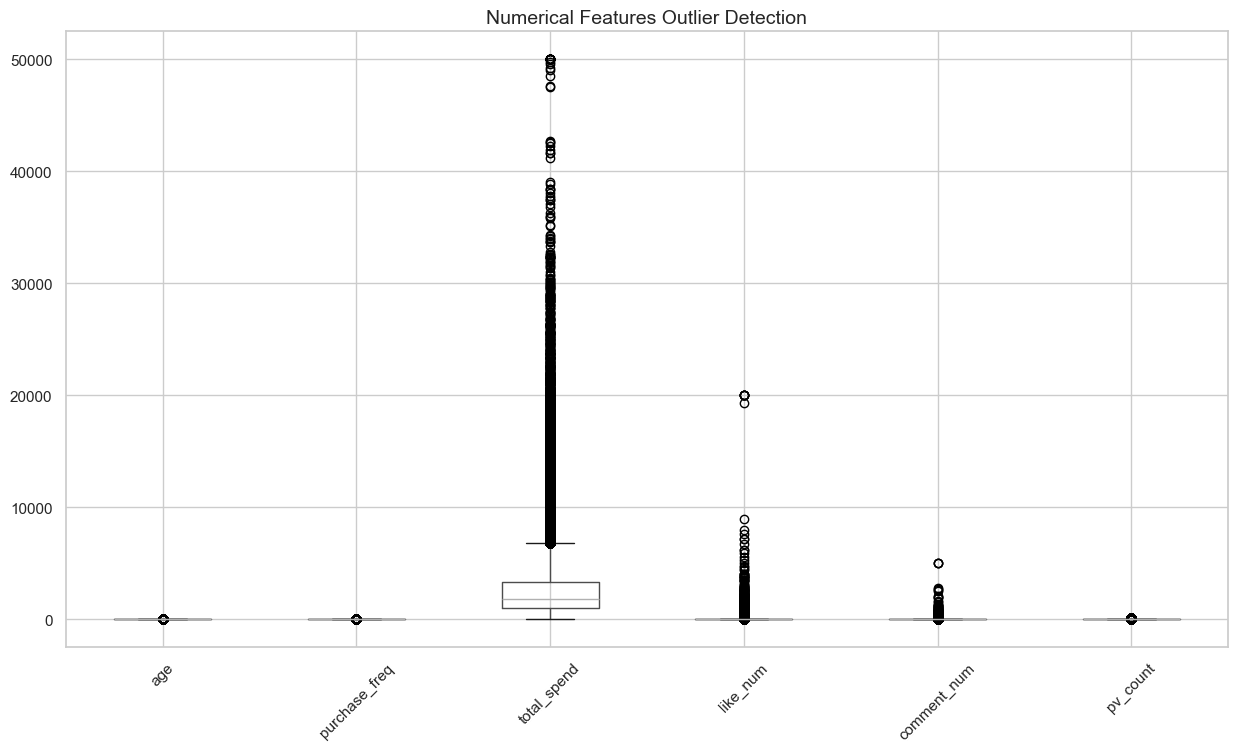

整体购买转化率 (CVR): 44.98%

--- 各特征与购买转化 (label) 的相关系数 ---
label               1.000000
add2cart            0.358893
coupon_used         0.200669
is_follow_author    0.125520
user_level          0.086435
discount_rate       0.061204
like_num            0.027025
collect_num         0.026908
comment_num         0.025150
img_count           0.005810
total_spend         0.002133
purchase_freq       0.002073
title_emo_score     0.001736
age                -0.000385
price              -0.010375
pv_count           -0.027863
last_click_gap     -0.067731
Name: label, dtype: float64
--- 特征偏度 (Skewness) 统计 ---
comment_num      61.933520
like_num         61.156057
total_spend       4.238478
pv_count          3.445703
purchase_freq     1.809810
age               0.537596
dtype: float64


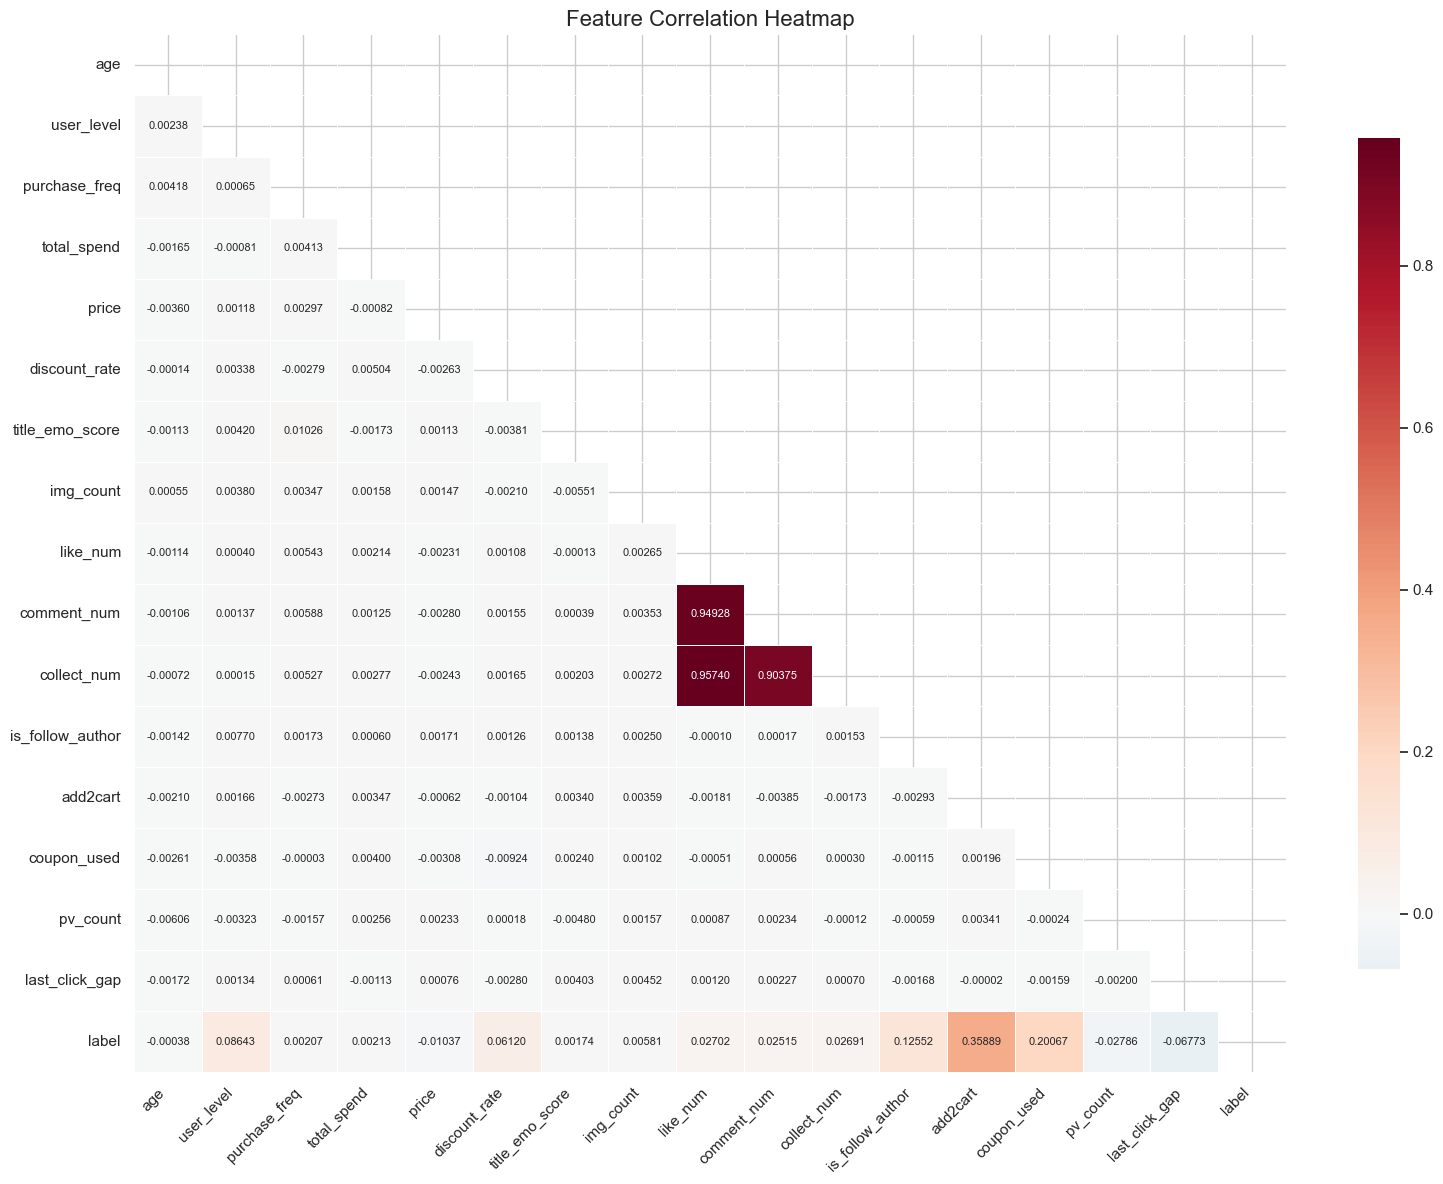

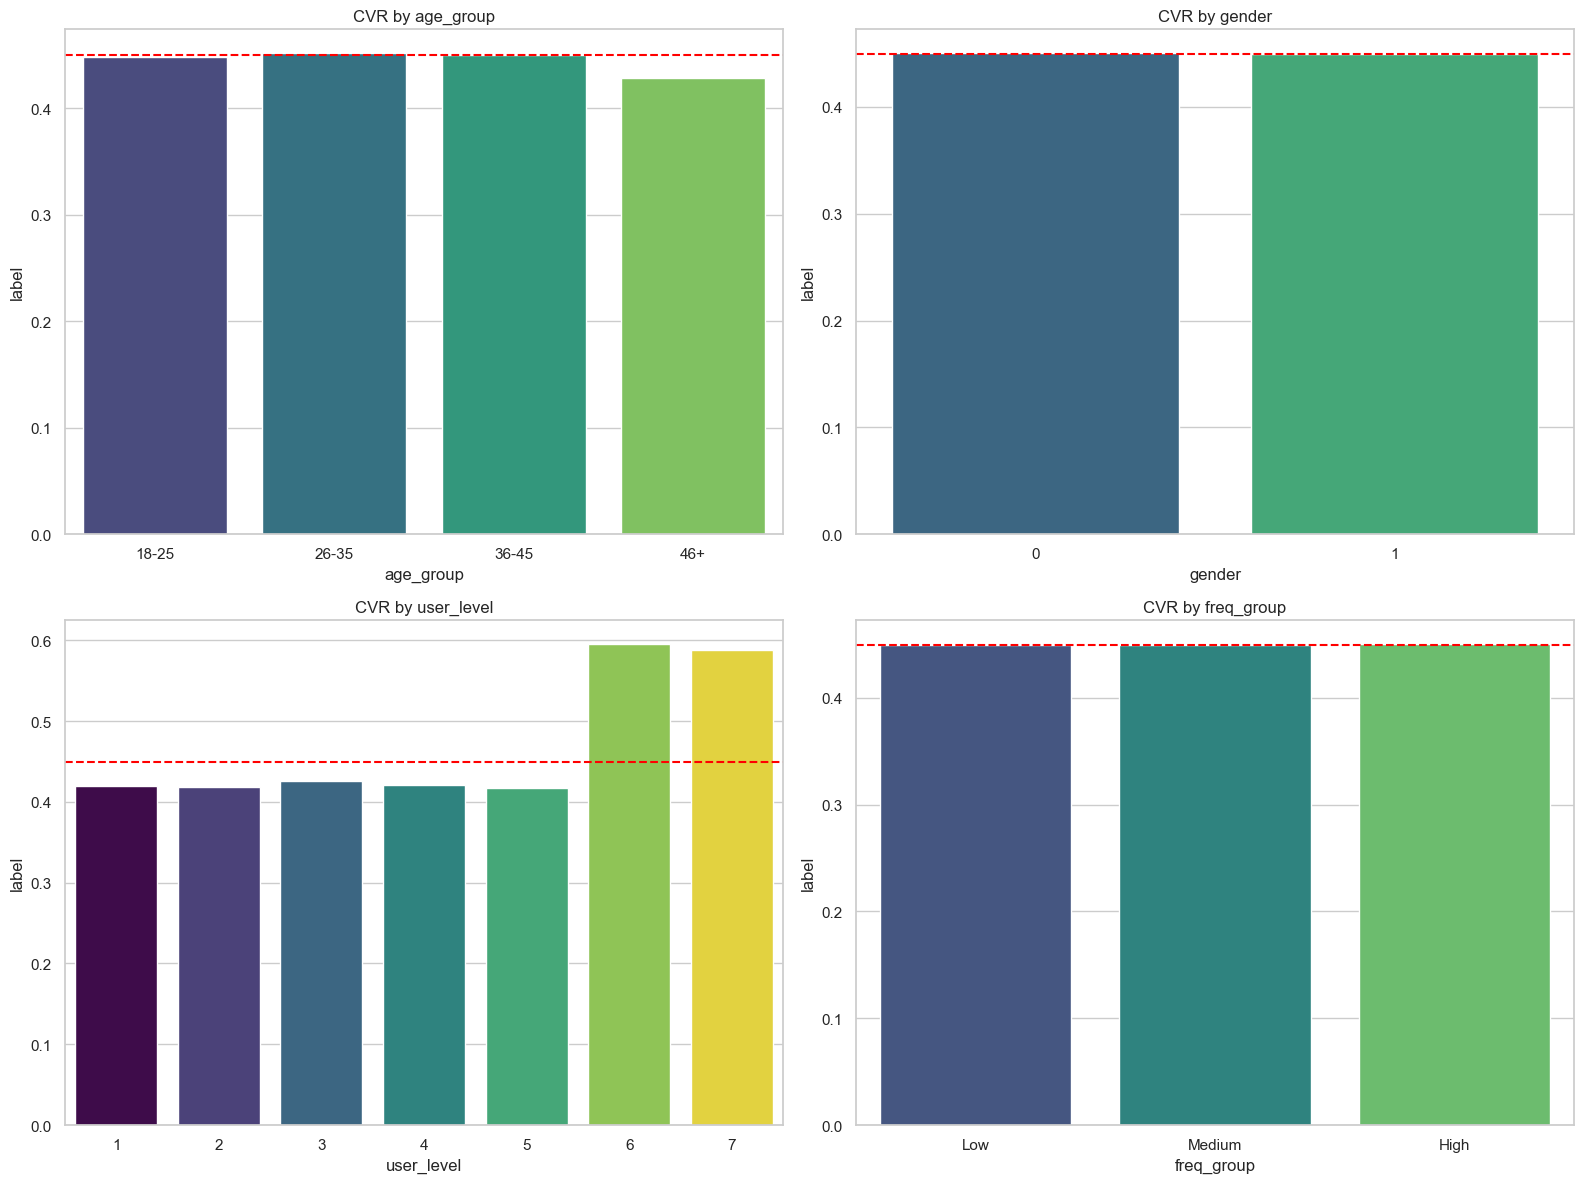

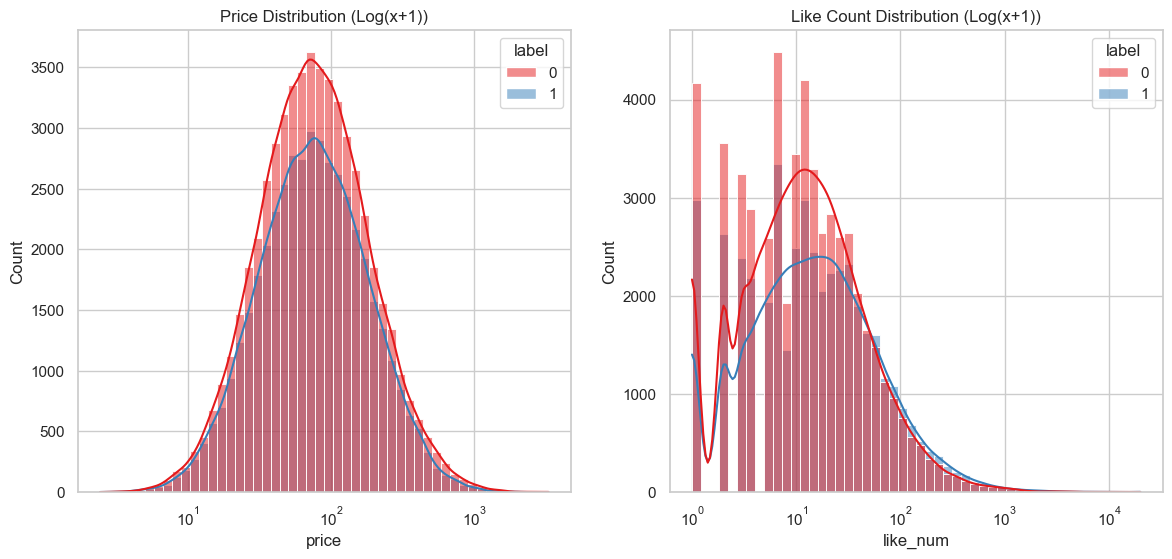

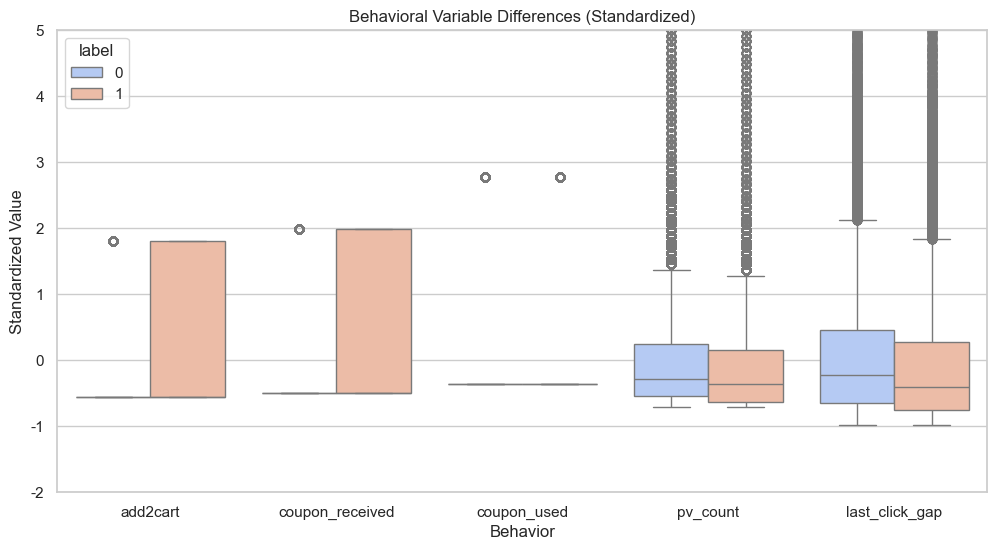

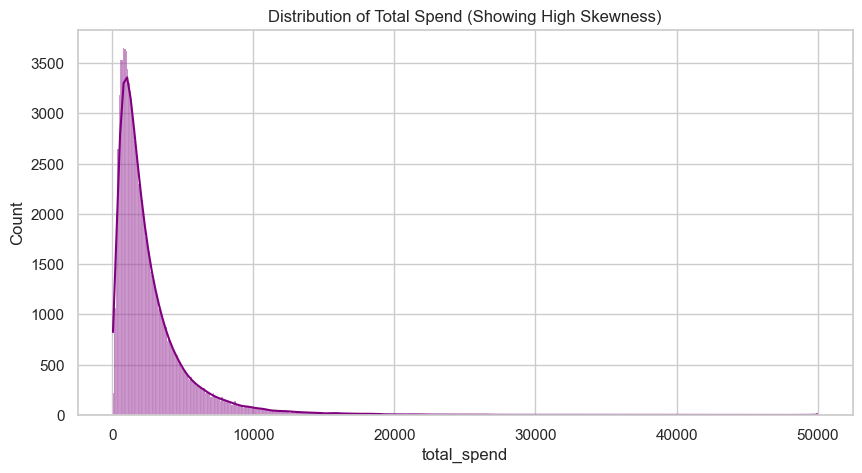

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 加载数据
df = pd.read_csv('social_ecommerce_data.csv')

# 检查缺失值
def check_missing(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_data = pd.DataFrame({
        'Missing Count': missing_count,
        'Percentage (%)': missing_percent
    }).sort_values(by='Percentage (%)', ascending=False)
    
    # 只显示有缺失的列
    return missing_data[missing_data['Missing Count'] > 0]

print("--- 数据缺失情况统计 ---")
print(check_missing(df))

# 异常值可视化与统计
def detect_outliers_iqr(df, features):
    outlier_indices = []
    print("--- 异常值统计 (基于 IQR 方法) ---")
    
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 记录异常值数量
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"{col}: 发现 {len(outliers)} 个异常值 (范围: <{lower_bound:.2f} 或 >{upper_bound:.2f})")
    
    # 绘制箱线图直观查看
    plt.figure(figsize=(15, 8))
    df[features].boxplot()
    plt.title("Numerical Features Outlier Detection", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# 选取需要检查的数值特征
numeric_features = ['age', 'purchase_freq', 'total_spend', 'like_num', 'comment_num', 'pv_count']
detect_outliers_iqr(df, numeric_features)

# --- (1) 整体转化率分析 ---
overall_cvr = df['label'].mean()
print(f"整体购买转化率 (CVR): {overall_cvr:.2%}\n")

# --- (2) 相关性分析与热力图 ---
# 选择关键特征（包含用户、内容、社交互动及交互变量）
corr_features = [
    'age', 'user_level', 'purchase_freq', 'total_spend', 
    'price', 'discount_rate', 'title_emo_score', 'img_count',
    'like_num', 'comment_num', 'collect_num', 'is_follow_author',
    'add2cart', 'coupon_used', 'pv_count', 'last_click_gap', 'label'
]

# 计算相关系数矩阵
corr_matrix = df[corr_features].corr()

# 打印与 label (购买转化) 相关系数的具体数值（按降序排列）
print("--- 各特征与购买转化 (label) 的相关系数 ---")
label_corr = corr_matrix['label'].sort_values(ascending=False)
print(label_corr)

# 绘制热力图
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 掩码隐藏上三角

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".5f",      
    cmap='RdBu_r', 
    center=0, 
    linewidths=.5, 
    annot_kws={"size": 8}, 
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)

# --- (3) 人群差异分析 ---
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 66], labels=['18-25', '26-35', '36-45', '46+'])
df['freq_group'] = pd.qcut(df['purchase_freq'], q=3, labels=['Low', 'Medium', 'High'])

group_cols = ['age_group', 'gender', 'user_level', 'freq_group']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(group_cols):
    cvr_data = df.groupby(col, observed=True)['label'].mean().reset_index()
    sns.barplot(x=col, y='label', data=cvr_data, hue=col, palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'CVR by {col}')
    axes[i].axhline(overall_cvr, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('conversion_demographics.png')

# --- (4) 右偏分布可视化 (使用 log(x+1)) ---
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x=df['price'] + 1, hue='label', kde=True, bins=50, palette='Set1', log_scale=True)
plt.title('Price Distribution (Log(x+1))')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x=df['like_num'] + 1, hue='label', kde=True, bins=50, palette='Set1', log_scale=True)
plt.title('Like Count Distribution (Log(x+1))')
plt.savefig('distribution_skewness.png')

# --- (5) 关键行为变量差异分析 (箱线图) ---
behavior_vars = ['add2cart', 'coupon_received', 'coupon_used', 'pv_count', 'last_click_gap']
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[behavior_vars]), columns=behavior_vars)
df_scaled['label'] = df['label']

plt.figure(figsize=(12, 6))
df_melted = df_scaled.melt(id_vars='label', var_name='Behavior', value_name='Standardized Value')
sns.boxplot(x='Behavior', y='Standardized Value', hue='label', data=df_melted, palette='coolwarm')
plt.title('Behavioral Variable Differences (Standardized)')
plt.ylim(-2, 5) 
plt.savefig('behavioral_differences.png')

## 增加偏度检查与可视化
def analyze_skewness(df, features):
    print("--- 特征偏度 (Skewness) 统计 ---")
    # 偏度 > 1 通常表示高度右偏
    skew_values = df[features].skew().sort_values(ascending=False)
    print(skew_values)
    
    # 可视化一个典型的偏态特征（如 total_spend）
    plt.figure(figsize=(10, 5))
    sns.histplot(df['total_spend'], kde=True, color='purple')
    plt.title("Distribution of Total Spend (Showing High Skewness)")
    plt.show()

analyze_skewness(df, numeric_features)